# Default running

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install lightgbm

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_val_predict, StratifiedKFold

# Loading&checking data  

In [5]:
# Uploading Trainset with Outliers and Missing Values Removed
X_t=pd.read_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_train_real.csv',encoding='cp949')
y_t=pd.read_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_train_real.csv',encoding='cp949')
X_v=pd.read_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_val_real.csv',encoding='cp949')
y_v=pd.read_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_val_real.csv',encoding='cp949')

'''X_t.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_train_f.csv', index=False)
y_t.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_train_f.csv', index=False)
X_v.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_val_f.csv', index=False)
y_v.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_val_f.csv', index=False)'''

"X_t.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_train_f.csv', index=False)\ny_t.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_train_f.csv', index=False)\nX_v.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/X_val_f.csv', index=False)\ny_v.to_csv('/content/drive/MyDrive/painkiller/datasets/preprocessed/y_val_f.csv', index=False)"

In [6]:
X_train_ori=X_t
y_train=y_t
X_val_ori=X_v
y_val=y_v

In [7]:
X_train_ori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17748 entries, 0 to 17747
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            17748 non-null  int64  
 1   n_tokens_title                17748 non-null  float64
 2   n_tokens_content              17748 non-null  float64
 3   n_unique_tokens               17748 non-null  float64
 4   n_non_stop_words              17748 non-null  float64
 5   n_non_stop_unique_tokens      17748 non-null  float64
 6   num_hrefs                     17748 non-null  float64
 7   num_self_hrefs                17748 non-null  float64
 8   num_imgs                      17748 non-null  float64
 9   num_videos                    17748 non-null  float64
 10  average_token_length          17748 non-null  float64
 11  num_keywords                  17748 non-null  float64
 12  kw_min_min                    17748 non-null  float64
 13  k

In [8]:
id_train = X_train_ori["id"].copy()
X_train = X_train_ori.drop(columns=["id"])

id_val = X_val_ori["id"].copy()
X_val = X_val_ori.drop(columns=["id"])


In [9]:
X_train.head(10)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,data_channel_Tech,data_channel_World,data_channel_unknown,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weekday_unknown
0,9.0,287.0,0.685512,1.0,0.853261,9.000000,0.0,1.000000,0.000000,4.696864,...,False,False,True,False,False,False,True,False,False,False
1,9.0,456.0,0.632458,1.0,0.751748,9.000000,6.0,3.000000,4.656854,4.526316,...,False,False,True,False,False,False,False,True,False,False
2,9.0,661.0,0.517504,1.0,0.749347,6.000000,3.0,1.000000,1.000000,4.897126,...,False,False,True,False,False,False,True,False,False,False
3,13.0,502.0,0.561224,1.0,0.705010,15.000000,2.0,9.000000,3.000000,4.529880,...,False,False,False,False,False,False,True,False,False,False
4,12.0,347.0,0.625731,1.0,0.815920,5.000000,3.0,1.000000,1.000000,4.593660,...,False,False,False,False,False,False,False,False,False,False
5,9.0,716.0,0.503587,1.0,0.673611,12.000000,3.0,13.000000,0.000000,5.134078,...,False,True,False,False,False,False,False,False,True,False
6,13.0,1037.0,0.454369,1.0,0.593703,7.000000,6.0,18.764235,0.000000,4.673095,...,False,False,False,False,False,False,False,False,False,False
7,12.0,472.0,0.372247,1.0,0.344743,48.899158,4.0,18.764235,1.000000,5.701271,...,False,False,False,False,True,False,False,False,False,False
8,12.0,408.0,0.582090,1.0,0.775000,6.000000,3.0,0.000000,4.656854,4.382353,...,True,False,False,False,False,False,False,False,True,False
9,15.0,946.0,0.483015,1.0,0.730994,1.000000,1.0,1.000000,2.000000,4.641649,...,False,True,False,False,False,False,True,False,False,False


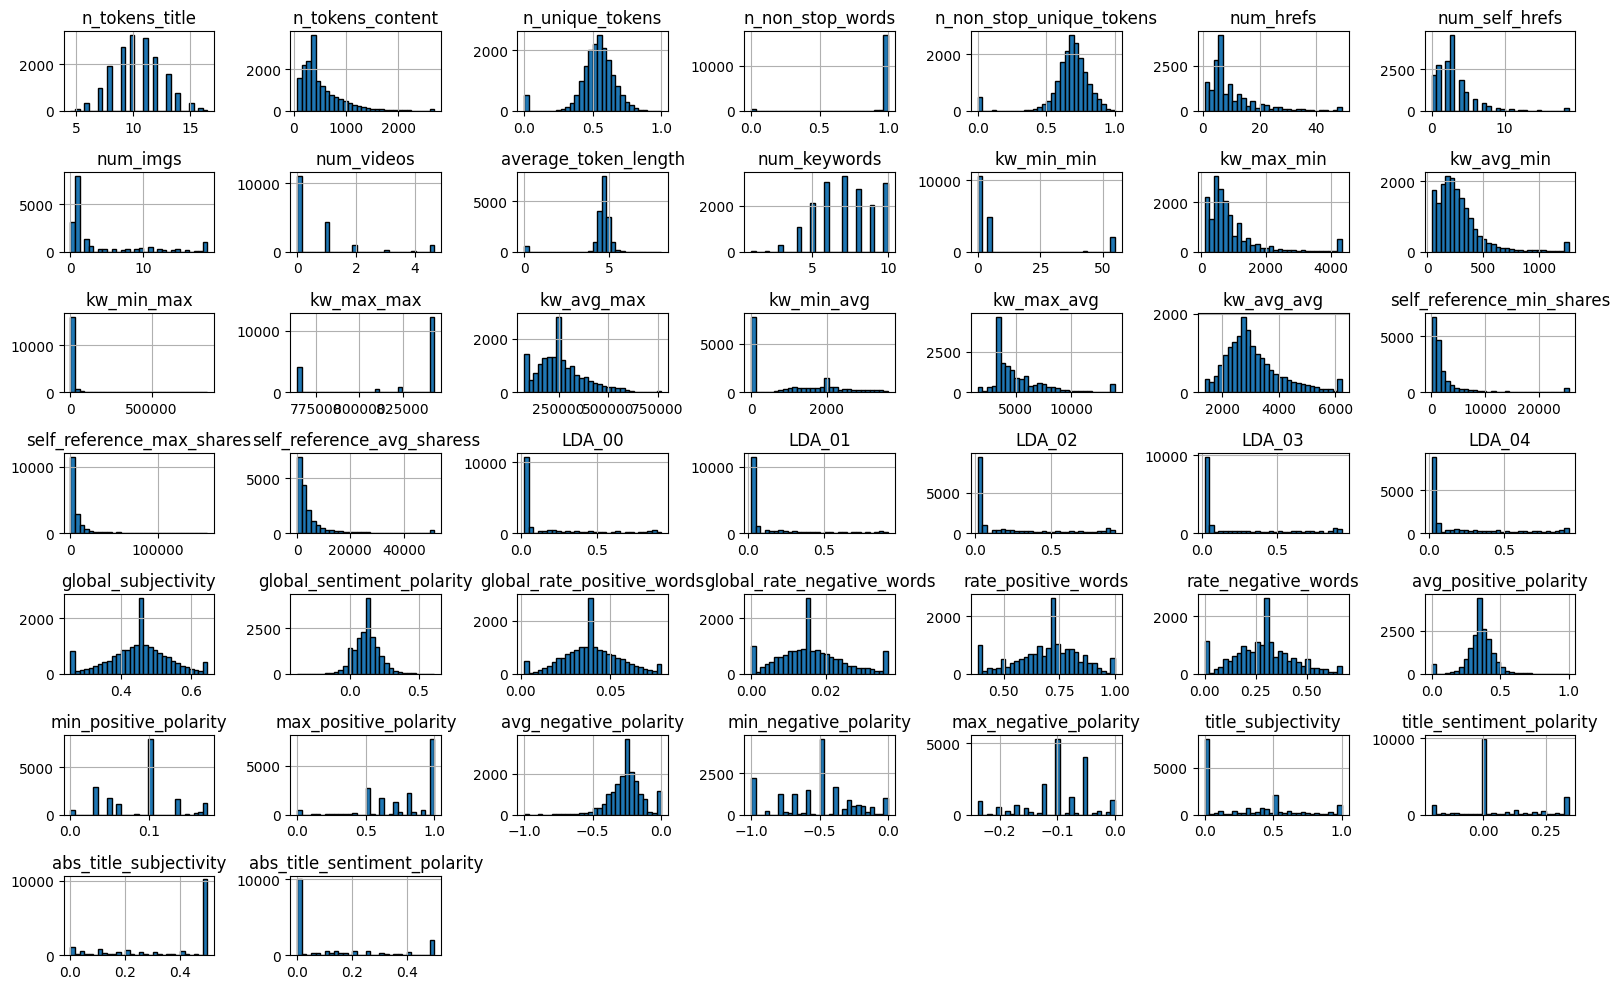

In [10]:
# Viewing distribution with cleaned data through a histogram
X_train.hist(bins=30, figsize=(16, 10), edgecolor='black') # only about numeric variables
plt.tight_layout()
plt.show()

In [11]:
X_train.skew()

,0
n_tokens_title,0.140519
n_tokens_content,2.077006
n_unique_tokens,-1.530706
n_non_stop_words,-5.506793
n_non_stop_unique_tokens,-2.355899
num_hrefs,2.082684
num_self_hrefs,2.503993
num_imgs,1.638873
num_videos,2.250791
average_token_length,-4.632020


# Data transformation

## log transformation

In [12]:
# Additional logarithmic transformation of long tail variables to the right based on skewness values and histogram visualizations
log_vars = [
    "n_tokens_content",
    "num_hrefs",
    "num_self_hrefs",
    "kw_max_min",
    "kw_avg_min",
    "self_reference_max_shares",
    "self_reference_min_shares",
    "self_reference_avg_sharess",
    "kw_avg_max"
]

def safe_log_transform(df, columns, epsilon=1e-5):
    df = df.copy()
    for col in columns:
        if col in df.columns:

            # Avoid negative numbers to ensure log stability
            df[col] = np.log1p(np.clip(df[col], epsilon, None))  # log1p(0)도 안전
    return df

X_train_logged = safe_log_transform(X_train, log_vars)
# Apply the same to val
X_val_logged = safe_log_transform(X_val, log_vars)

In [14]:
# re-checking null or not
X_train_logged.isnull().sum()
X_val_logged.isnull().sum()

,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
n_non_stop_words,0
n_non_stop_unique_tokens,0
num_hrefs,0
num_self_hrefs,0
num_imgs,0
num_videos,0
average_token_length,0


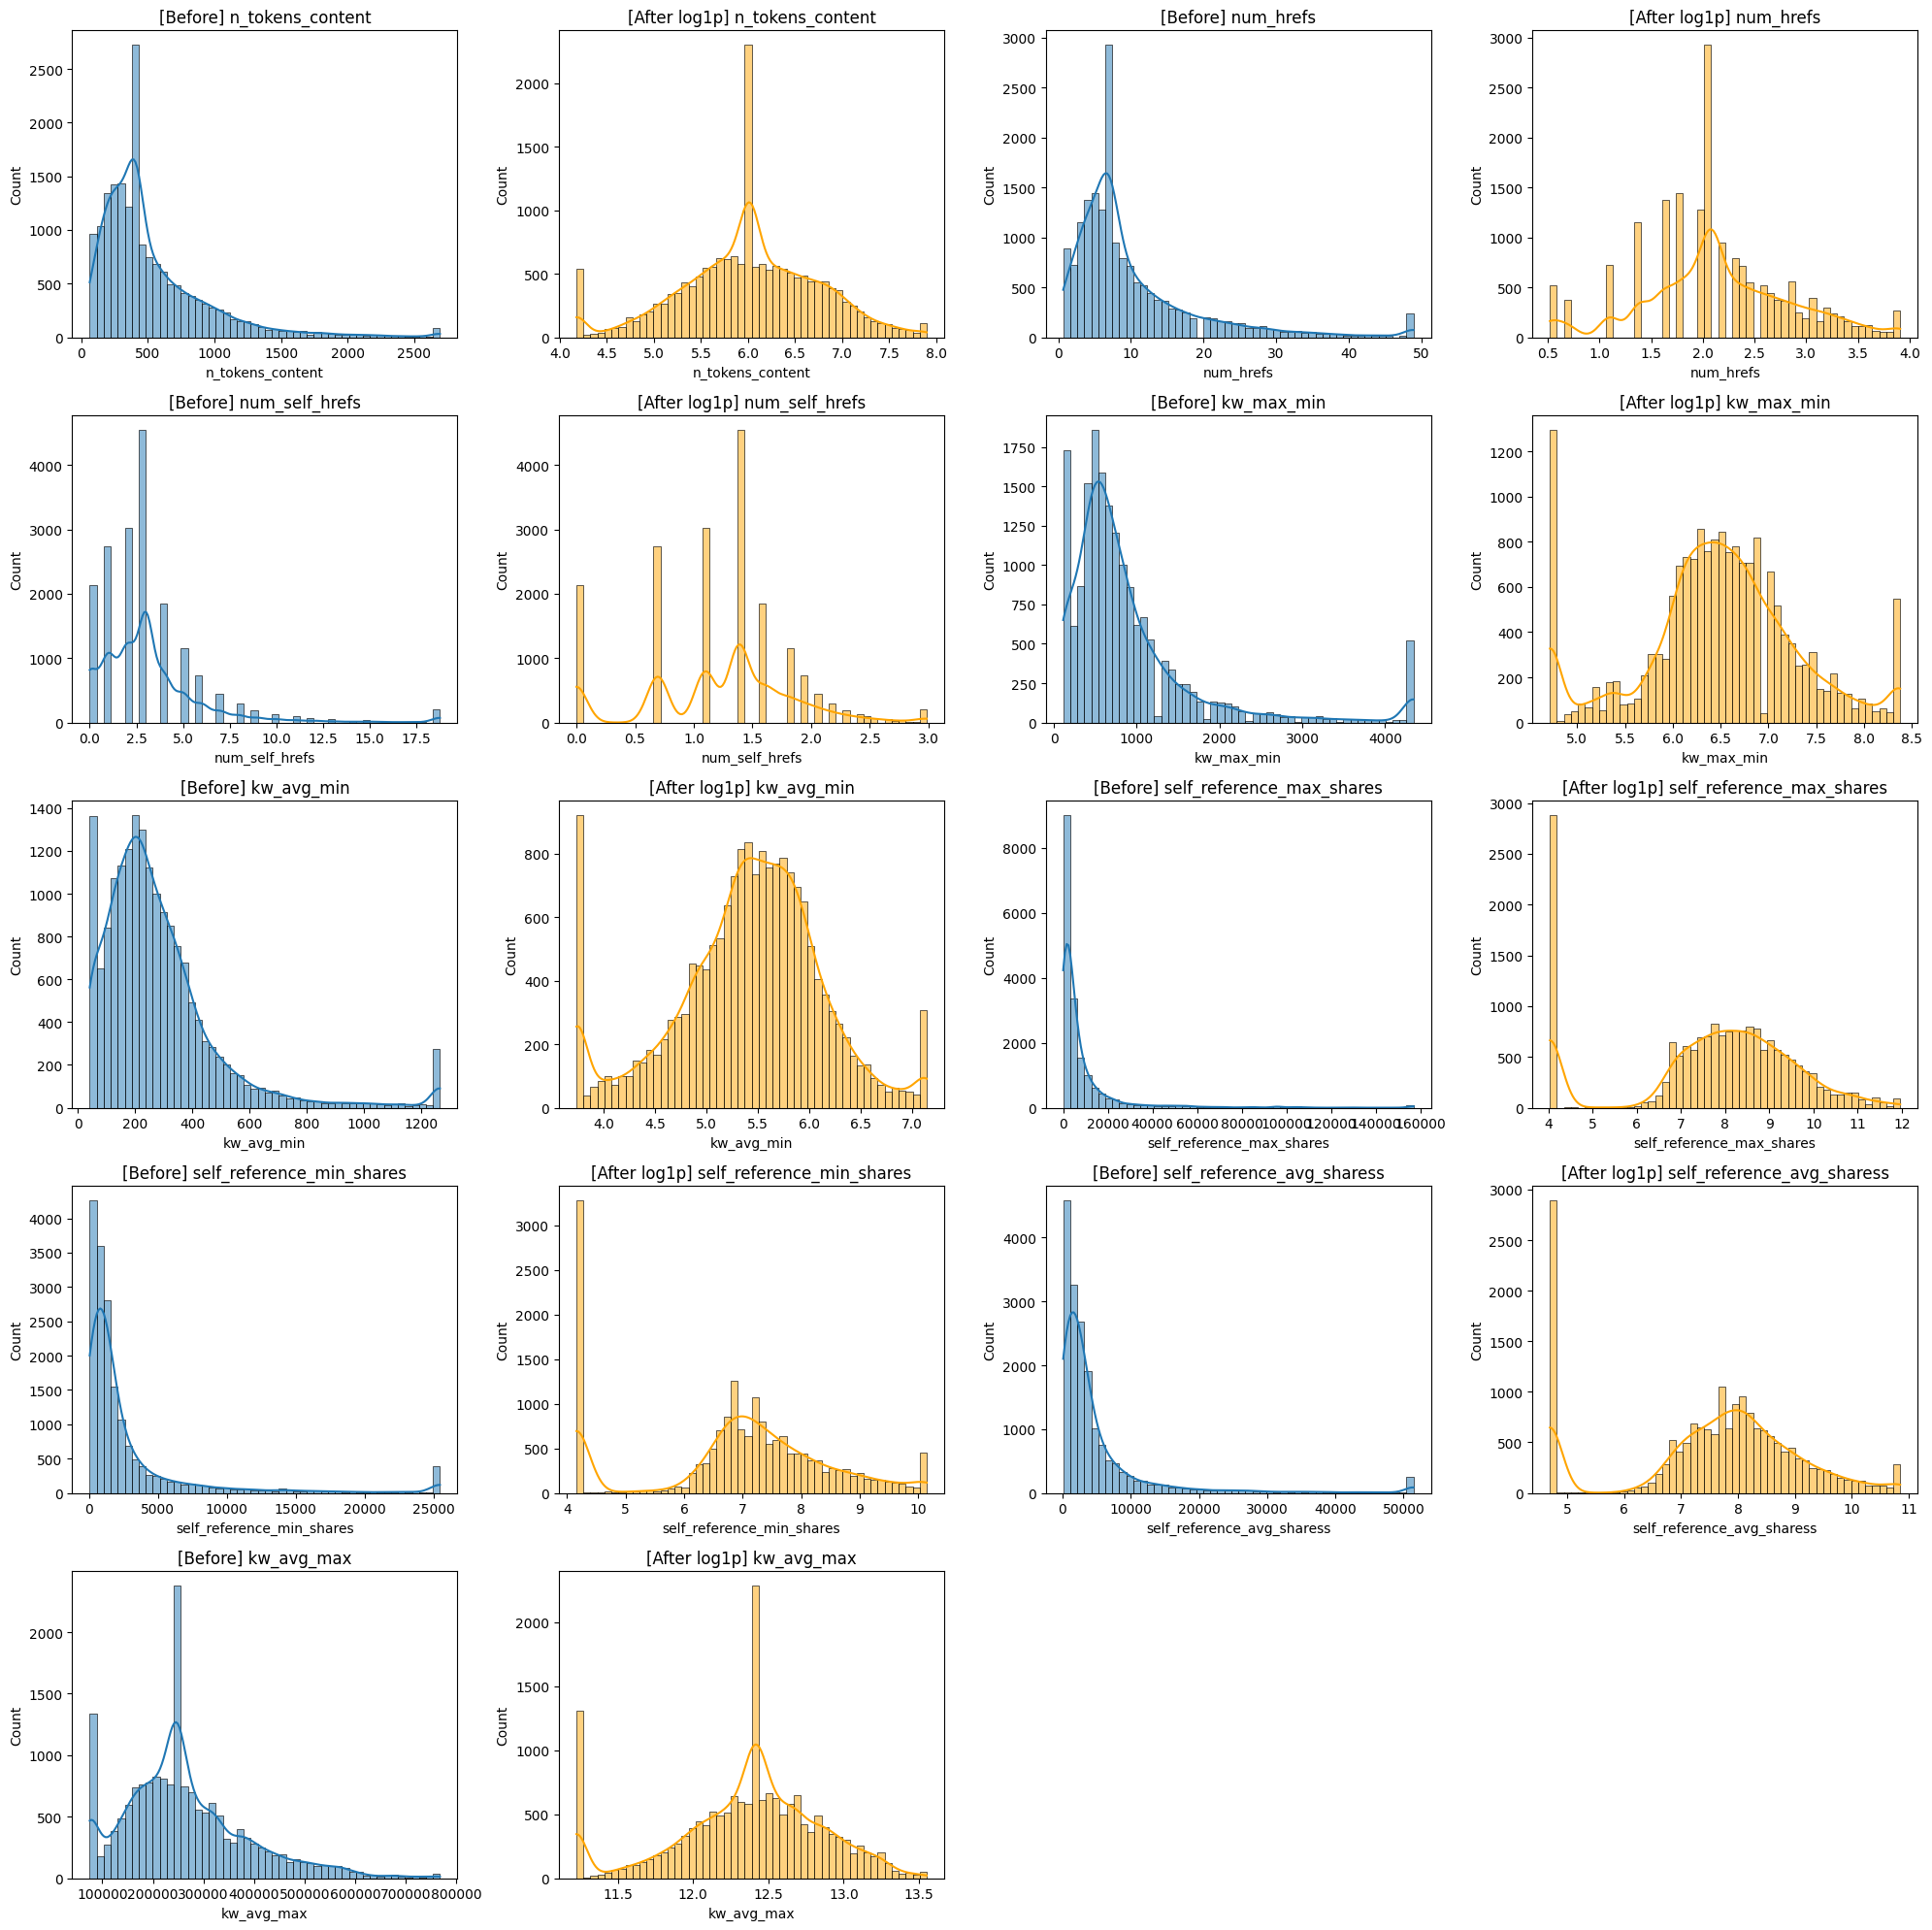

In [15]:
# Comparison before and after log conversion
def compare_log_transform_4col(df_before, df_after, columns, bins=50):
    n = len(columns)
    n_cols = 4  # [Before], [After] x 각 변수
    n_rows = math.ceil(n * 2 / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        # Before
        sns.histplot(df_before[col], bins=bins, kde=True, ax=axes[i*2])
        axes[i*2].set_title(f"[Before] {col}")

        # After
        sns.histplot(df_after[col], bins=bins, kde=True, ax=axes[i*2 + 1], color="orange")
        axes[i*2 + 1].set_title(f"[After log1p] {col}")


    for j in range(i*2 + 2, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
compare_log_transform_4col(X_train, X_train_logged, log_vars)

In [16]:
# Redefining value
X_train=X_train_logged
X_val=X_val_logged

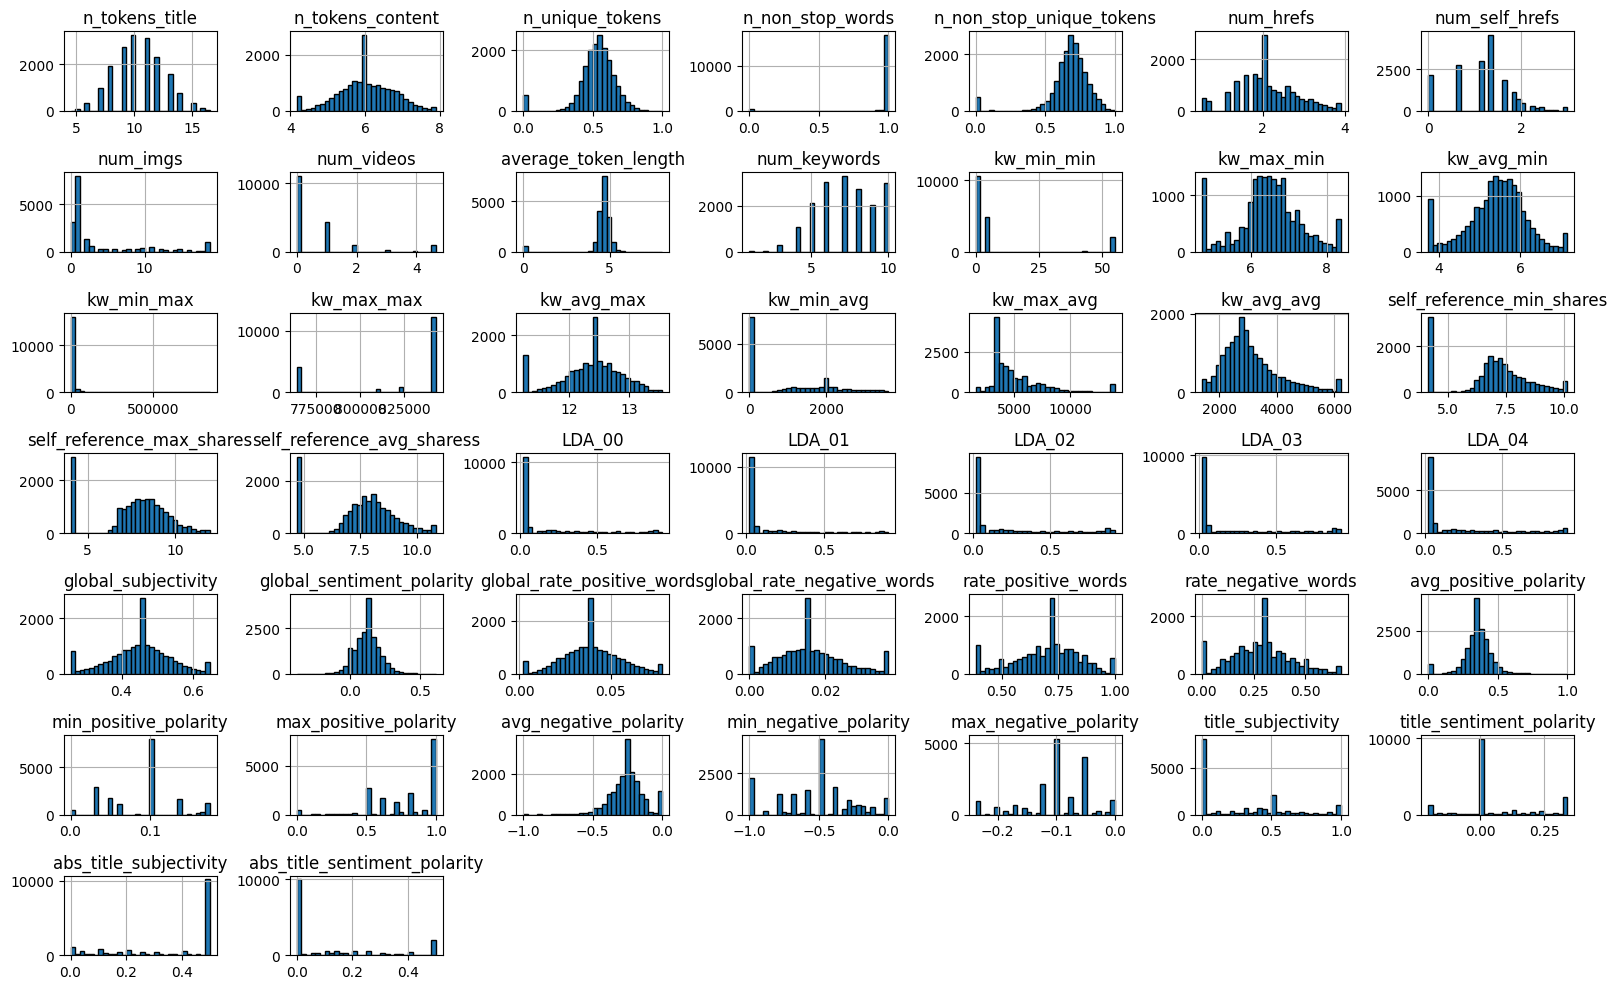

In [18]:
# Viewing whole distribution after log transformation
X_train.hist(bins=30, figsize=(16, 10), edgecolor='black') # only about numeric variables
plt.tight_layout()
plt.show()

## scaling

Due to the nature of the tree-based model, scaling is deemed unnecessary. So, I didn't scale it.

# Data engineering

## Identifying important features based on various base_model

Checking the importance of existing variables (46) based on the candidate base models to use


*   For identifying key existing variables with high reliability





In [19]:
# 1. RandomForest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
#print(classification_report(y_val, y_pred))

# Checking the importance of variables
feature_importances_rf = pd.Series(
    rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# Selecting Top-10
top_rf = feature_importances_rf.head(10).index.tolist()
print("Top_10 important features:\n", feature_importances_rf.head(10))

Top_10 important features:
 kw_avg_avg                    0.045801
kw_max_avg                    0.041251
LDA_02                        0.034143
LDA_04                        0.031235
LDA_01                        0.030851
LDA_00                        0.030267
self_reference_avg_sharess    0.028915
self_reference_min_shares     0.028803
n_unique_tokens               0.028752
kw_avg_max                    0.028385
dtype: float64


In [20]:
# 2. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_val)
#print(classification_report(y_val, y_pred))

# Checking the importance of variables
feature_importances_gb = pd.Series(
    gb.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# Selecting Top-10
top_gb = feature_importances_gb.head(10).index.tolist()
print("Top_10 important features:\n", feature_importances_gb.head(10))

Top_10 important features:
 kw_avg_avg                    0.139909
kw_max_avg                    0.079997
self_reference_min_shares     0.069733
weekday_Saturday              0.053757
data_channel_Tech             0.048194
kw_min_avg                    0.045414
data_channel_Entertainment    0.043478
n_unique_tokens               0.038352
LDA_04                        0.037014
LDA_00                        0.035971
dtype: float64


In [21]:
# 3. catBoost
cb=CatBoostClassifier(verbose=0, random_state=42)
cb.fit(X_train, y_train)
y_pred = cb.predict(X_val)
#print(classification_report(y_val, y_pred))

# Checking the importance of variables
feature_importances_cb = pd.Series(
    cb.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# Selecting Top-10
top_cb = feature_importances_cb.head(10).index.tolist()
print("Top_10 important features :\n", feature_importances_cb.head(10))

Top_10 important features :
 kw_avg_avg                   4.952575
kw_max_avg                   4.201669
self_reference_min_shares    3.530342
LDA_02                       3.514548
n_unique_tokens              3.413801
LDA_00                       3.386123
kw_min_avg                   3.222238
LDA_01                       2.875381
self_reference_max_shares    2.780451
average_token_length         2.751730
dtype: float64


In [22]:
# Identifying important variables in common across all three models
common_features = set(top_rf) & set(top_gb) & set(top_cb)
print("Common Top features:", common_features)

Common Top features: {'LDA_00', 'self_reference_min_shares', 'kw_max_avg', 'n_unique_tokens', 'kw_avg_avg'}


## Designing derivative variables

1. Designing derivative variables associated with common variables in importance

# Related to LDA Topics
topic_cols = [col for col in X_cols.columns if col.startswith("LDA_")]
X_cols["lda_focus"] = X_cols[topic_cols].max(axis=1) # Strongest topic probability value
X_cols["dominant_topic"] = X_cols[topic_cols].idxmax(axis=1).str.extract("(\d+)").astype(int) # Strongest Topic Number
X_cols["topic_entropy"] = X_cols[topic_cols].apply(
    lambda row: -np.sum([p * np.log(p + 1e-9) for p in row]), axis=1) # Diversity of subject distribution (topic concentration)

# Related to Day/Channel Related
X_cols['is_weekend'] = X_cols['weekday'].apply(lambda x: 1 if x in ['Saturday', 'Sunday', 5, 6] else 0) # Weekend or not
group_map = {
    'lifestyle': 'soft',
    'entertainment': 'soft',
    'business': 'hard',
    'tech': 'hard',
    'world': 'hard',
    'social media': 'misc'
}
X_cols['channel_grouped'] = X_cols['data_channel'].map(group_map)

# Related to kw_variables
X_cols["kw_ratio"]=X_cols["kw_max_avg"]/(X_cols["kw_min_avg"]+1e-5) # Extreme Ratio → whether a particular keyword is concentrated
X_cols["kw_skew"]=(X_cols["kw_max_avg"]+1)/(X_cols["kw_avg_avg"]+1) # Top Keyword Influence → Unbiased or not
X_cols["kw_max_boost"]=X_cols["kw_max_max"]/(X_cols["kw_avg_max"]) # Relative influence of the strongest keywords

# Related to self_reference_variables
X_cols["selfref_boost"] = X_cols["self_reference_avg_sharess"] / (X_cols["average_token_length"] + 1e-5) # Self-reference effect against content length
X_cols["selfref_ratio"] = X_cols["num_self_hrefs"] / (X_cols["num_hrefs"] + 1e-5) # Self-reference percentage of all links
X_cols["selfref_aggressiveness"] = X_cols["num_self_hrefs"] / (X_cols["n_tokens_content"] + 1e-5) # frequency of self-promotion relative to length of the text

2. Designing derivative variables based on domain knowledge and problem definitions

*   Problem definition: binary classification that predicts whether an article has been shared more than 1400 times


X_cols["token_density"]=X_cols["n_tokens_content"]/(1+X_cols["n_tokens_content"]) # Compression diagram of a title versus a text
X_cols["nonstop_token_ratio"]=X_cols["n_non_stop_words"]/X_cols["n_tokens_content"] # the percentage of stopwords
X_cols["pos_neg_ratio"]=X_cols["global_rate_positive_words"]/(1+X_cols["global_rate_negative_words"]) # positive/negative ratio
X_cols["emotion_contrast"]=X_cols["max_positive_polarity"]-X_cols["min_negative_polarity"] # Emotional amplitude
X_cols["kw_avg_gap"]=X_cols["kw_max_avg"]-X_cols["kw_min_avg"] # Width of Keyword Score(Judgment of Concentration)
X_cols["neg_ratio"]=abs(X_cols["global_sentiment_polarity"]) # Polar Strength (shocking/selection likely)

## SHAP Analysis based on existing and derived variables

For checking Which features contribute to the actual prediction in the entire set of features that coexist with existing variables


*  In other words, Filtering only variables that contribute to actual predictions among existing features and a number of generated features
*  Applying SHAP to all existing + derivative variables to identify significant top variables



Determining and visualizing the importance of variables using SHAP

In [23]:
# Preparing data with existing and derivative variables
# Creating a new DataFrame by adding all derivative variables to existing variables
# Add a total of 19 derivatives
def add_all_derived_features(df):
    df = df.copy()  # Existing X_train is untouched, adds a column of derivatives added to the copy of X_train, and returns the whole

    # related to LDA
    topic_cols = [col for col in df.columns if col.startswith("LDA_")]
    df["lda_focus"] = df[topic_cols].max(axis=1)
    df["dominant_topic"] = df[topic_cols].idxmax(axis=1).str.extract("(\d+)").astype(int)
    df["topic_entropy"] = df[topic_cols].apply(
        lambda row: -np.sum([p * np.log(p + 1e-9) for p in row]), axis=1
    )

    # related weekday and channel
    def safe_get_bool(df, col):
        return df[col].astype(int) if col in df.columns else pd.Series([0] * len(df), index=df.index)

    # is_weekend
    df["is_weekend"] = (
        safe_get_bool(df, "weekday_Saturday") |
        safe_get_bool(df, "weekday_Sunday")
    )

    # channel group
    df["channel_group_soft"] = (
        safe_get_bool(df, "channel_lifestyle") |
        safe_get_bool(df, "channel_entertainment")
    )
    df["channel_group_hard"] = (
        safe_get_bool(df, "channel_business") |
        safe_get_bool(df, "channel_tech") |
        safe_get_bool(df, "channel_world")
    )
    df["channel_group_misc"] = safe_get_bool(df, "channel_social media")


    # related to kw
    df["kw_ratio"] = df["kw_max_avg"] / (df["kw_min_avg"] + 1e-5)
    df["kw_skew"] = (df["kw_max_avg"] + 1) / (df["kw_avg_avg"] + 1)
    df["kw_max_boost"] = df["kw_max_max"] / (df["kw_avg_max"] + 1e-5)
    df["kw_avg_gap"] = df["kw_max_avg"] - df["kw_min_avg"]

    # related self_reference
    df["selfref_boost"] = df["self_reference_avg_sharess"] / (df["average_token_length"] + 1e-5)
    df["selfref_ratio"] = df["num_self_hrefs"] / (df["num_hrefs"] + 1e-5)
    df["selfref_aggressiveness"] = df["num_self_hrefs"] / (df["n_tokens_content"] + 1e-5)

    # Other emotion and language structure-based derivatives
    df["token_density"] = df["n_tokens_content"] / (1 + df["n_tokens_title"])
    df["nonstop_token_ratio"] = df["n_non_stop_words"] / (df["n_tokens_content"] + 1e-5)
    df["pos_neg_ratio"] = df["global_rate_positive_words"] / (1 + df["global_rate_negative_words"])
    df["emotion_contrast"] = df["max_positive_polarity"] - df["min_negative_polarity"]
    df["neg_ratio"] = abs(df["global_sentiment_polarity"])

    return df


In [24]:
# Complete set of variables including both existing variables and new derivative variables
# Data frames with existing + derivatives
X_train_aug = add_all_derived_features(X_train)
X_val_aug = add_all_derived_features(X_val)
print(X_train_aug.columns )

Index(['n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
       'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
       'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max',
       'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg',
       'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03',
       'LDA_04', 'global_subjectivity', 'global_sentiment_polarity',
       'global_rate_positive_words', 'global_rate_negative_words',
       'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity',
       'min_positive_polarity', 'max_positive_polarity',
       'avg_negative_polarity', 'min_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'data_channel

In [25]:
# Learning Model
model = CatBoostClassifier(verbose=0, random_state=42)
model.fit(X_train_aug, y_train)

In [26]:
# Calculate SHAP Values
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_aug)

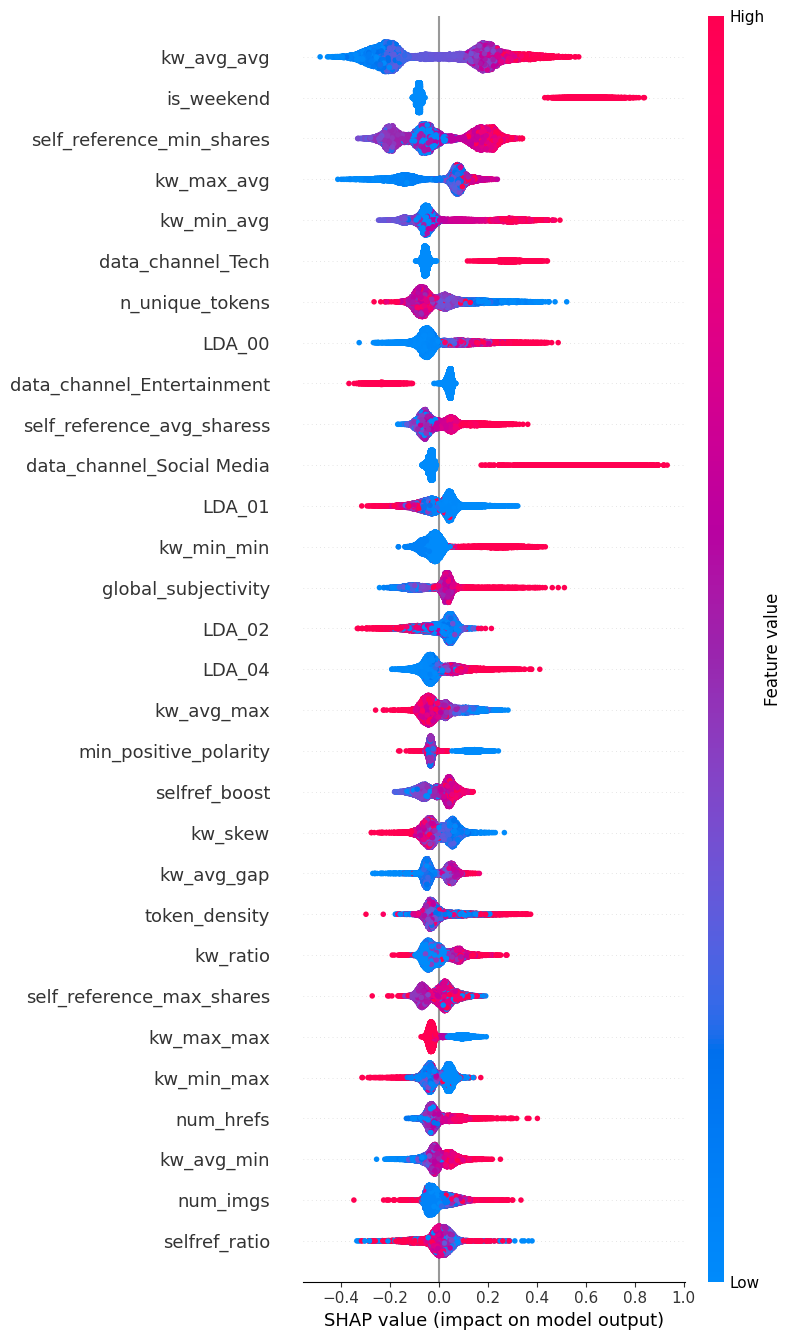

In [27]:
# Visualize Contribution with SHAP summary plot
# Visualize the top 30 features (out of a total of 76 features) based on SHAP values => Existing variables vs. determining how high the derivative is
# Evaluate the validity of derivatives among SHAP parent variables
shap.summary_plot(shap_values, X_train_aug, max_display=30)

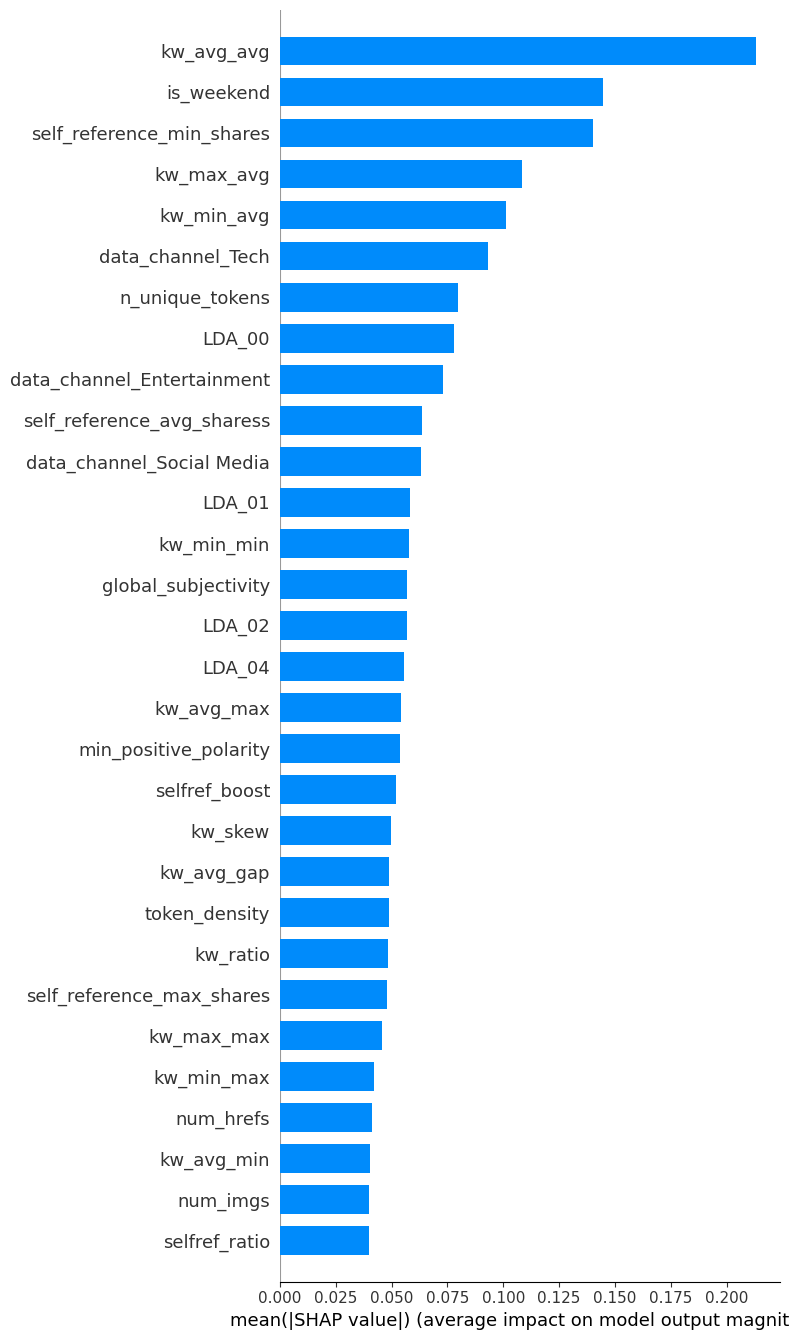

In [28]:
# (additional) Sort simple importance with Bar Plot
shap.summary_plot(shap_values, X_train_aug, plot_type="bar", max_display=30)


Checking the included derivative variables

In [29]:
# total 19, list of derivative variables
derived_features = derived_features = [
    "lda_focus","dominant_topic","topic_entropy", # LDA
    "is_weekend","channel_group_soft","channel_group_hard","channel_group_misc", # weekday/channel
     "kw_ratio","kw_skew","kw_max_boost","kw_avg_gap", # kw
    "selfref_boost","selfref_ratio","selfref_aggressiveness", # self_ref
    "token_density","nonstop_token_ratio","pos_neg_ratio","emotion_contrast","neg_ratio"]  # language and emotion


In [30]:
# Choose only the top variables from the SHAP results and compare them with the list of derivatives
# The most influential variable top 25 (visualization is for a total of 30 features)
top_feature_names = np.array(X_train_aug.columns)[np.argsort(np.abs(shap_values).mean(0))[::-1][:25]]

# Filter only derivatives
derived_in_top = [f for f in top_feature_names if f in derived_features]

print("Derivatives of SHAP Top 25 Variables:", derived_in_top)

Derivatives of SHAP Top 25 Variables: ['is_weekend', 'selfref_boost', 'kw_skew', 'kw_avg_gap', 'token_density', 'kw_ratio']


## Evaluating the validity of the derivative variable

SHAP 상위 변수 중 파생변수의 유효성 평가 => 파생변수들이 실제로 예측 성능 향상에 기여하는지 검증

In [31]:
# Performance metrics for existing variables (without derivatives) based on CV
# Same model cat as when calculating SHAP
# model = CatBoostClassifier(verbose=0, random_state=42)
from sklearn.model_selection import cross_val_score
# cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_ori = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
auc_scores_ori = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"[CV 평가] F1 mean: {f1_scores_ori.mean():.4f}, AUC mean: {auc_scores_ori.mean():.4f}") # only score

[CV 평가] F1 mean: 0.6610, AUC mean: 0.7212


In [ ]:
# Validation with CV of sole effect of each derivative f1 & AUC
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

selected_features = list(X_train.columns)  # existing
# derived variables_candidates
derived_candidates = ['is_weekend', 'selfref_boost', 'kw_skew', 'kw_avg_gap', 'token_density', 'kw_ratio']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for feat_name in derived_candidates:
    temp_feats = selected_features + [feat_name]
    X_temp = X_train_aug[temp_feats]

    f1_scores = []
    auc_scores = []

    for train_idx, val_idx in cv.split(X_temp, y_train):
        X_tr, X_val = X_temp.iloc[train_idx], X_temp.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        probas = model.predict_proba(X_val)[:, 1]

        f1_scores.append(f1_score(y_val, preds))
        auc_scores.append(roc_auc_score(y_val, probas))

    results.append({
        "feature_added": feat_name,
        "mean_f1": np.mean(f1_scores),
        "mean_auc": np.mean(auc_scores)
    })

In [ ]:
print(pd.DataFrame(results))

In [ ]:
df_results = pd.DataFrame(results)

# Set reference point (Baseline value)
baseline_f1 = f1_scores_ori.mean()
baseline_auc = auc_scores_ori.mean()

# Calculate and decide whether to adopt the enhancement
df_results["F1_Gain"] = df_results["mean_f1"] - baseline_f1
df_results["AUC_Gain"] = df_results["mean_auc"] - baseline_auc
df_results["Selected"] = (df_results["F1_Gain"] > 0) & (df_results["AUC_Gain"] > 0)

# Visualization
plt.figure(figsize=(12, 5))

# F1 # Visualization
plt.subplot(1, 2, 1)
plt.bar(df_results["feature_added"], df_results["mean_f1"],
        color=df_results["Selected"].map({True: "green", False: "gray"}))
plt.axhline(baseline_f1, linestyle="--", color="red", label=f"Baseline F1 = {baseline_f1:.3f}")
plt.ylabel("F1 Score")
plt.title("F1 Score by Feature")
plt.xticks(rotation=45)
plt.legend()

# AUC # Visualization
plt.subplot(1, 2, 2)
plt.bar(df_results["feature_added"], df_results["mean_auc"],
        color=df_results["Selected"].map({True: "green", False: "gray"}))
plt.axhline(baseline_auc, linestyle="--", color="red", label=f"Baseline AUC = {baseline_auc:.3f}")
plt.ylabel("AUC Score")
plt.title("AUC Score by Feature")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 결과 출력
print(df_results)


## Determining the Derivatives to Add

In [ ]:
selected_new_features = ['is_weekend', 'kw_skew', 'kw_avg_gap', 'token_density']

# final feature (exisiting + Selected Derivatives)
final_features = selected_features + selected_new_features

In [ ]:
# check
final_features

Recalculating model-wide performance with CV, including selected derivatives

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

# final feature set
X_final = X_train_aug[final_features]

f1_scores, auc_scores = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(X_final, y_train):
    X_tr, X_vl = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_tr, y_vl = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)
    y_proba = model.predict_proba(X_vl)[:, 1]

    f1_scores.append(f1_score(y_vl, y_pred))
    try:
        auc_scores.append(roc_auc_score(y_vl, y_proba))
    except ValueError:
        auc_scores.append(np.nan)  # Exceptions NaN

# print mean
print("CV")
print(f"F1 mean:  {np.nanmean(f1_scores):.4f}")
print(f"AUC mean: {np.nanmean(auc_scores):.4f}")


# Final feature

In [ ]:
# Attaching the final variable to the source data
def add_selected_derived_features(df):
    df = df.copy()

    df["is_weekend"] = (
        safe_get_bool(df, "weekday_Saturday") |
        safe_get_bool(df, "weekday_Sunday")
    )

    df["kw_skew"] = (df["kw_max_avg"] + 1) / (df["kw_avg_avg"] + 1)
    df["kw_avg_gap"] = df["kw_max_avg"] - df["kw_min_avg"]
    df["token_density"] = df["n_tokens_content"] / (1 + df["n_tokens_title"])

    return df

X_train_final = add_selected_derived_features(X_train.copy())[selected_features + selected_new_features]
X_val_final = add_selected_derived_features(X_val.copy())[selected_features + selected_new_features]



In [ ]:
# check
X_train_final.info()

In [ ]:
# checking distribution of new features
import matplotlib.pyplot as plt
import seaborn as sns

derived_features = selected_new_features  # ['is_weekend', 'kw_skew', 'kw_avg_gap', 'token_density']

n_cols = 2
n_rows = int(np.ceil(len(derived_features) / n_cols))

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(derived_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X_train_final[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
# Preprocessing Derivative Variables
log_vars = ['kw_avg_gap', 'token_density']
X_train_final[log_vars] = np.log1p(np.clip(X_train_final[log_vars], a_min=0, a_max=None))
X_val_final[log_vars] = np.log1p(np.clip(X_val_final[log_vars], a_min=0, a_max=None))


In [ ]:
# Save final feature (id value not attached)
X_train_final.to_csv("/content/drive/MyDrive/painkiller/datasets/X_train_final.csv", index=False)
X_val_final.to_csv("/content/drive/MyDrive/painkiller/datasets/X_val_final.csv", index=False)
y_train.to_csv("/content/drive/MyDrive/painkiller/datasets/y_train.csv", index=False)
y_val.to_csv("/content/drive/MyDrive/painkiller/datasets/y_val.csv", index=False)


# Testset

In [ ]:
X_test =